In [1]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/abdulsamad010/mall-customerrr/Mall_Customers.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head())

(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


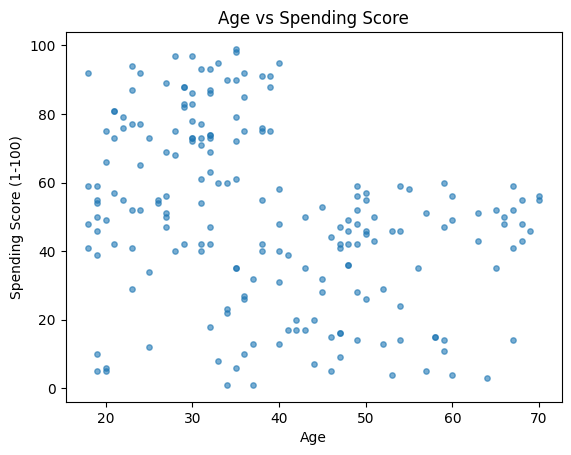

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"],
    s=15,
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending Score")
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [5]:
df["Cluster"] = kmeans.predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


In [6]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
score = silhouette_score(X_scaled, df["Cluster"])

print(f"Silhouette Score: {score:.3f}")

# Calculate average values for each cluster
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print("\nCluster Summary:")
print(cluster_summary)

Silhouette Score: 0.417

Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064
